In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go
import time
from datetime import timedelta
import json
import os
import psutil
import gc
import math

# 强制进行垃圾回收（释放循环引用等未被引用的对象）
gc.collect()  
# Set device to GPU if available
device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
############ customization
length = 48
width = 48
n1 = 13
n2 = 13
judge = 0

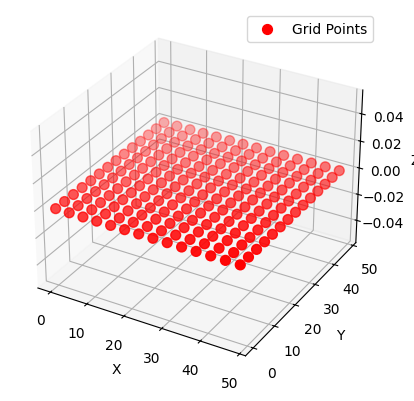

In [3]:
############### Problem context formulation

def generate_rectangular_grid_sg(length, width, n1, n2=2, judge=1, z=0, height=0):
    x_points = [i * (length / n1) for i in range(n1 + 1)]
    y_points = [j * (width / n2) for j in range(n2, -1, -1)]

    grid_points = []
    for x in x_points:
        for y in y_points:
            if y == width / 2:
                grid_points.append([x, y, height])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

def generate_connectivity_matrix(new_coords):
    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}
    connectivity = []

    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:
        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 

        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  

        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

grid_points = generate_rectangular_grid_sg(length, width, n1, n2, judge)
connectivity = generate_connectivity_matrix(grid_points)
plot_grid(grid_points, length, width)


###########################################################################################################################################################
n_dof_per_node = 6  # Degrees of freedom per node
grid_points = torch.tensor(grid_points, device=device, dtype=torch.float32)
total_dof = n_dof_per_node * len(grid_points)

########## Surrounding fixed
x_max = grid_points[:, 0].max()
x_min = grid_points[:, 0].min()
y_max = grid_points[:, 1].max()
y_min = grid_points[:, 1].min()

Fixed_nodes = torch.where(
    ((grid_points[:, 0] == x_max) & (grid_points[:, 1] == y_max)) |  # (x_max, y_max)
    ((grid_points[:, 0] == x_max) & (grid_points[:, 1] == y_min)) |  # (x_max, y_min)
    ((grid_points[:, 0] == x_min) & (grid_points[:, 1] == y_max)) |  # (x_min, y_max)
    ((grid_points[:, 0] == x_min) & (grid_points[:, 1] == y_min))    # (x_min, y_min)
)[0]

Fixed_nodes += 1
Free_nodes = []

n_elements = len(connectivity)
n_nodes = len(grid_points)

for i in range(1, n_nodes + 1):
    if i not in Fixed_nodes:
        Free_nodes.append(i)


####### BCs
fixed_dof = []
for node in Fixed_nodes:
    fixed_dof.extend([(node - 1) * 6 + i for i in range(6)])

##########################################################################################################################################################
##########################################################################################################################################################

In [4]:
rows = n2 + 1
cols = n1 + 1

idx_matrix = [[0 for _ in range(cols)] for _ in range(rows)]

for k in range(rows * cols):
    row = k % rows
    col = k // rows
    idx_matrix[row][col] = k
V_matrix = torch.arange(0, n2 * (n1 + 1)).reshape(n1 + 1, n2).T

start = n2 * (n1 + 1)
H_matrix = torch.arange(start, start + (n2 + 1) * n1)
H_matrix = H_matrix.reshape(n1 + 1 , n2)
H_matrix = H_matrix.flip(0)
print(V_matrix)
print(H_matrix)

tensor([[  0,  13,  26,  39,  52,  65,  78,  91, 104, 117, 130, 143, 156, 169],
        [  1,  14,  27,  40,  53,  66,  79,  92, 105, 118, 131, 144, 157, 170],
        [  2,  15,  28,  41,  54,  67,  80,  93, 106, 119, 132, 145, 158, 171],
        [  3,  16,  29,  42,  55,  68,  81,  94, 107, 120, 133, 146, 159, 172],
        [  4,  17,  30,  43,  56,  69,  82,  95, 108, 121, 134, 147, 160, 173],
        [  5,  18,  31,  44,  57,  70,  83,  96, 109, 122, 135, 148, 161, 174],
        [  6,  19,  32,  45,  58,  71,  84,  97, 110, 123, 136, 149, 162, 175],
        [  7,  20,  33,  46,  59,  72,  85,  98, 111, 124, 137, 150, 163, 176],
        [  8,  21,  34,  47,  60,  73,  86,  99, 112, 125, 138, 151, 164, 177],
        [  9,  22,  35,  48,  61,  74,  87, 100, 113, 126, 139, 152, 165, 178],
        [ 10,  23,  36,  49,  62,  75,  88, 101, 114, 127, 140, 153, 166, 179],
        [ 11,  24,  37,  50,  63,  76,  89, 102, 115, 128, 141, 154, 167, 180],
        [ 12,  25,  38,  51,  64,  77,  

In [5]:
def Symmetry_shaper(q, matrix):

    rows, cols = matrix.shape

    row_odd = rows % 2 == 1
    col_odd = cols % 2 == 1
    
    if row_odd:

        q = torch.cat([q, q.flip(0)[1:,:]], dim=0)
    else:

        q = torch.cat([q, q.flip(0)], dim=0)
    

    if col_odd:

        q = torch.cat([q, q.flip(1)[:,1:]], dim=1)
    else:

        q = torch.cat([q, q.flip(1)], dim=1)
    
    return q
    

In [6]:
############################################################# Force condition
def Force_mat(F_value, F_type, total_dof=total_dof, Free_nodes=Free_nodes, judge=0):
    
    F = torch.zeros(total_dof, dtype=torch.float32, device=device)
    
    if judge == 0:
        F_value = torch.tensor([F_value] * len(Free_nodes), device=device) * 1000 # The force value/direction
        F_type = [F_type] * len(Free_nodes)  # The force type
    else:
        F_value = torch.tensor(F_value) * 1000
        F_value = torch.tensor(F_type)
    
    for idx, i in enumerate(Free_nodes):
        F[6 * (i - 1) + F_type[idx]] = F_value[idx]  # unit: KN / KN*m
        
    return F, F_value

In [7]:
def save_fdm(state_idx, grid_points, new_node_coords, 
            connectivity, Free_nodes, Fixed_nodes, force, SED,
            save_dir="results", max_states=6):
    """
    多状态组合图保存函数
    
    参数:
        state_idx: 状态序号 (0=初始, 1=第cut次, 2=第2*cut次...)
        max_states: 组合图中最多显示的状态数
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # 数据准备
    x_orig = grid_points[:, 0].cpu().detach().numpy()
    y_orig = grid_points[:, 1].cpu().detach().numpy()
    z_orig = grid_points[:, 2].cpu().detach().numpy()
    
    x_fdm = new_node_coords[:, 0].cpu().detach().numpy()
    y_fdm = new_node_coords[:, 1].cpu().detach().numpy()
    z_fdm = new_node_coords[:, 2].cpu().detach().numpy()
    
    # 计算当前高度
    current_height = max(z_fdm)
    
    # 初始化图形容器
    if not hasattr(save_fdm, 'fig'):
        save_fdm.fig = plt.figure(figsize=(24, 16))
        save_fdm.axes = [save_fdm.fig.add_subplot(2, 3, i+1, projection='3d') 
                       for i in range(max_states)]
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
        save_fdm.saved_states = 0
        save_fdm.max_z = 0  # 用于统一z轴尺度
    
    # 检查是否已存满
    if save_fdm.saved_states >= max_states:
        filename = os.path.join(save_dir, f"FDM_States_{max_states}.png")
        save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close(save_fdm.fig)
        delattr(save_fdm, 'fig')
        delattr(save_fdm, 'axes')
        delattr(save_fdm, 'saved_states')
        delattr(save_fdm, 'max_z')
        print(f"Saved full states to {filename}")
        return
    
    # 更新最大z值（用于统一坐标尺度）
    if current_height > save_fdm.max_z:
        save_fdm.max_z = current_height
    
    # 获取当前子图并清除旧内容
    ax = save_fdm.axes[save_fdm.saved_states]
    ax.clear()
    
    # ========== 可视化绘制 ==========
    # 1. 绘制原始网格（浅灰色虚线）
    for i, j in connectivity:
        ax.plot([x_orig[i-1], x_orig[j-1]],
                [y_orig[i-1], y_orig[j-1]],
                [z_orig[i-1], z_orig[j-1]], 
                ':', color='#CCCCCC', linewidth=0.8, alpha=0.7)
    
    # 2. 绘制当前状态网格
    color = '#1f77b4' if state_idx == 0 else '#ff7f0e'  # 初始蓝色，迭代橙色
    for i, j in connectivity:
        ax.plot([x_fdm[i-1], x_fdm[j-1]],
                [y_fdm[i-1], y_fdm[j-1]],
                [z_fdm[i-1], z_fdm[j-1]], 
                '-', color=color, linewidth=1.8, alpha=0.9)
    
    # 3. 标记固定节点（黑色实心圆）
    for node in Fixed_nodes:
        ax.scatter(x_fdm[node-1], y_fdm[node-1], z_fdm[node-1],
                  c='black', s=50, marker='o', alpha=0.8)
    
    # 4. 添加高度标注（替换原来的力值标注）
    ax.text(x=0.05, y=0.90, z=save_fdm.max_z*1.05,
           s=f"Height: {current_height:.2f}m\nSE: {SED:.8f} ", 
           transform=ax.transAxes, 
           fontsize=10,
           bbox=dict(facecolor='white', alpha=0.7))
    
    # ========== 子图装饰 ==========
    ax.set_xlabel('X (m)', fontsize=9)
    ax.set_ylabel('Y (m)', fontsize=9)
    ax.set_zlabel('Z (m)', fontsize=9)
    ax.set_title(f"State {state_idx}" if state_idx > 0 else "Initial State", 
                fontsize=11, pad=12)
    ax.set_zlim(0, save_fdm.max_z * 1.1)  # 统一z轴尺度
    ax.view_init(elev=35, azim=45)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # 更新状态计数器
    save_fdm.saved_states += 1
    
    # 如果是最后一个状态，立即保存
    if save_fdm.saved_states == max_states:
        filename = os.path.join(save_dir, f"FDM_States_{max_states}.png")
        save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close(save_fdm.fig)
        delattr(save_fdm, 'fig')
        delattr(save_fdm, 'axes')
        delattr(save_fdm, 'saved_states')
        delattr(save_fdm, 'max_z')
        print(f"Saved full states to {filename}")


def finalize_fdm(save_dir="results", completed=False):
    """
    最终化处理函数
    
    参数:
        save_dir: 保存目录
        completed: 是否完成所有迭代 (True=已完成全部迭代，False=提前终止)
    """
    if not hasattr(save_fdm, 'fig') or save_fdm.saved_states == 0:
        return
    
    # 如果已完成所有迭代，保存当前进度（不强制填满）
    if completed:
        filename = os.path.join(save_dir, 
                              f"FDM_States_completed_{save_fdm.saved_states}.png")
    # 如果是提前终止，保存上一次有效迭代
    else:
        # 回退一个状态，因为最后一次迭代可能不完整
        save_fdm.saved_states = max(0, save_fdm.saved_states - 1)
        filename = os.path.join(save_dir,
                              f"FDM_States_partial_{save_fdm.saved_states+1}.png")
    
    # 保存图像
    save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
    plt.close(save_fdm.fig)
    
    # 打印保存信息
    if completed:
        print(f"Saved completed states ({save_fdm.saved_states}/{len(save_fdm.axes)}) to {filename}")
    else:
        print(f"Saved last valid state ({save_fdm.saved_states+1}) to {filename}")
    
    # 清理属性
    for attr in ['fig', 'axes', 'saved_states', 'max_z']:
        if hasattr(save_fdm, attr):
            delattr(save_fdm, attr)







In [8]:
####### FDM part 
C = torch.zeros(n_elements, n_nodes, dtype=torch.float32, device=device)
for n, (i, j) in enumerate(connectivity):
    C[n, i - 1] = 1
    C[n, j - 1] = -1
    
px= torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)
py = torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)
pz = torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)


fixed_idces = torch.tensor([node - 1 for node in Fixed_nodes], device=device)
free_node_indices = torch.tensor([node - 1 for node in Free_nodes], device=device)

CF = C[:, fixed_idces]
CN = C[:, free_node_indices]

def FDM(Q, F_value, node_coords, CN=CN, CF=CF, px=px, py=py, pz=pz, 
        fixed_idces=fixed_idces, free_node_indices=free_node_indices,
        ):
    
    pz[:, 0] = F_value
        
    Dn = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CN))
    DF = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CF))
    
    
    xF = node_coords[fixed_idces, 0].unsqueeze(1)
    yF = node_coords[fixed_idces, 1].unsqueeze(1)
    zF = node_coords[fixed_idces, 2].unsqueeze(1)
    
    xN = torch.matmul(torch.inverse(Dn), (px - torch.matmul(DF, xF)))
    yN = torch.matmul(torch.inverse(Dn), (py - torch.matmul(DF, yF)))
    zN = torch.matmul(torch.inverse(Dn), (pz - torch.matmul(DF, zF)))
        
    
    new_node_coords = node_coords.clone()
    new_node_coords[free_node_indices, 0] = xN.squeeze()
    new_node_coords[free_node_indices, 1] = yN.squeeze()
    new_node_coords[free_node_indices, 2] = zN.squeeze()
    
    return new_node_coords

In [9]:
###### FE part
D_radius = 0.75
D_young_modulus = 10e9 
D_shear_modulus = 0.7e9 
D_poisson_ratio = 0.3
cross_section_angle_a = 0  
cross_section_angle_b = 0  
a_small_number = 1e-10

def rotation(v, k, theta):
    """Rotation of vector v around axis k by angle theta."""
    k = k / torch.norm(k)  # Normalize k
    cross_product = torch.cross(k, v)
    dot_product = torch.dot(k, v)

    # Ensure theta is a tensor
    theta = torch.tensor(theta, dtype=torch.float32, device=device) if not isinstance(theta, torch.Tensor) else theta

    v_rotated = v * torch.cos(theta) + cross_product * torch.sin(theta) + k * dot_product * (1 - torch.cos(theta))
    return v_rotated

class Beam:
    def __init__(self, node_coordinates, R=D_radius, young_modulus=D_young_modulus,
                 shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                 Beta_b=cross_section_angle_b):
        self.node_coordinates = node_coordinates  # (2, 3) tensor for node coordinates

        # Material and geometry
        self.radius = R
        self.young_modulus = young_modulus
        self.shear_modulus = shear_modulus
        self.poisson_ratio = poisson_ratio

        # Cross-sectional properties
        self.length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])  # Length of the beam
        self.Iy = (torch.pi * self.radius ** 4) / 4 
        self.Iz = self.Iy
        self.A = torch.pi * self.radius ** 2
        self.J = (torch.pi * self.radius ** 4) / 2

        # Stiffness components
        self.S_u = self.young_modulus * self.A / self.length
        self.S_v1a = 12 * self.young_modulus * self.Iy / (self.length ** 3)
        self.S_v1b = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_v2a = 12 * self.young_modulus * self.Iz / (self.length ** 3)
        self.S_v2b = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta1a = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_theta1b = 4 * self.young_modulus * self.Iy / self.length
        self.S_theta1c = 2 * self.young_modulus * self.Iy / self.length
        self.S_theta2a = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta2b = 4 * self.young_modulus * self.Iz / self.length
        self.S_theta2c = 2 * self.young_modulus * self.Iz / self.length
        self.S_Tr = self.shear_modulus * self.J / self.length

        # Section rotations at the two ends
        self.Beta_a = Beta_a
        self.Beta_b = Beta_b

    def get_element_stiffness_matrix(self):
        """Element stiffness matrix."""
        K_element = torch.tensor([
            [self.S_u, 0, 0, 0, 0, 0, -self.S_u, 0, 0, 0, 0, 0],
            [0, self.S_v1a, 0, 0, 0, self.S_theta1a, 0, -self.S_v1a, 0, 0, 0, self.S_theta1a],
            [0, 0, self.S_v2a, 0, -self.S_theta2a, 0, 0, 0, -self.S_v2a, 0, -self.S_theta2a, 0],
            [0, 0, 0, self.S_Tr, 0, 0, 0, 0, 0, -self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2b, 0, 0, 0, self.S_v2b, 0, self.S_theta2c, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1b, 0, -self.S_v1b, 0, 0, 0, self.S_theta1c],
            [-self.S_u, 0, 0, 0, 0, 0, self.S_u, 0, 0, 0, 0, 0],
            [0, -self.S_v1a, 0, 0, 0, -self.S_theta1a, 0, self.S_v1a, 0, 0, 0, -self.S_theta1a],
            [0, 0, -self.S_v2a, 0, self.S_theta2a, 0, 0, 0, self.S_v2a, 0, self.S_theta2a, 0],
            [0, 0, 0, -self.S_Tr, 0, 0, 0, 0, 0, self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2c, 0, 0, 0, self.S_v2b, 0, self.S_theta2b, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1c, 0, -self.S_v1b, 0, 0, 0, self.S_theta1b],
        ], dtype=torch.float32, device=device)

        return K_element

    def System_Transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        matrix_T = torch.zeros((12, 12), dtype=torch.float32, device=device)
        for i in range(0, 12, 3):
            matrix_T[i:i + 3, i:i + 3] = lambda_matrix
        return matrix_T

    def nodal_transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        return lambda_matrix


def assemble_stiffness_matrix(beams, n_nodes, n_dof_per_node, connectivity):
    """Global stiffness matrix assembly."""
    total_dof = n_nodes * n_dof_per_node  # Total degrees of freedom
    K_global = torch.zeros((total_dof, total_dof), dtype=torch.float32, device=device)
    
    for idx, (i, j) in enumerate(connectivity):
        Matrix_T = beams[idx].System_Transform()  # Get transformation matrix
        K_element = torch.matmul(torch.transpose(Matrix_T, 0, 1),
                                 torch.matmul(beams[idx].get_element_stiffness_matrix(), Matrix_T))

        start_idx = (i - 1) * n_dof_per_node
        end_idx = (j - 1) * n_dof_per_node
        K_global[start_idx:start_idx + 6, start_idx:start_idx + 6] += K_element[0:6, 0:6]
        K_global[end_idx:end_idx + 6, end_idx:end_idx + 6] += K_element[6:12, 6:12]
        K_global[start_idx:start_idx + 6, end_idx:end_idx + 6] += K_element[0:6, 6:12]
        K_global[end_idx:end_idx + 6, start_idx:start_idx + 6] += K_element[6:12, 0:6]

    return K_global

def robust_solve(K_global, F, fixed_dof, max_attempts=3):
    
    attempts = 0
    while attempts < max_attempts:
        reg = 1e-6 * torch.eye(K_global.shape[0], device=K_global.device)
        reg[fixed_dof, fixed_dof] = 0  
        K_reg = K_global + reg
        
        try:
            displacements = torch.linalg.solve(
                K_reg.to(torch.float64), 
                F.to(torch.float64)
            )
            return displacements.to(K_global.dtype)
            
        except RuntimeError:
            diag = torch.diag(K_global)
            extreme_mask = (diag > 1e12) & (~torch.isin(torch.arange(len(diag)), torch.tensor(fixed_dof)))  
            K_reg[extreme_mask] = 0
            K_reg[:, extreme_mask] = 0
            K_reg[extreme_mask, extreme_mask] = 1e12  
            
            K_reg[fixed_dof, :] = 0
            K_reg[:, fixed_dof] = 0
            K_reg[fixed_dof, fixed_dof] = 1e10  
            
            try:
                displacements, info = torch.linalg.cg(
                    K_reg.to(torch.float64),
                    F.to(torch.float64),
                    maxiter=5000,
                    atol=1e-6
                )
                if info > 0:
                    raise RuntimeError("CG nah nah")
                return displacements.to(K_global.dtype)
                
            except:
                K_pinv = torch.linalg.pinv(K_reg)
                K_pinv[fixed_dof, :] = 0  
                displacements = K_pinv @ F
                print("警告：使用伪逆求解，精度可能降低")
                return displacements
                
        attempts += 1
    
    raise RuntimeError("无法求解线性系统")


def Strain_E(node_coords, connectivity, fixed_dof, F):
    # Element Assembly
    Beam_lens = []
    beams = []
    for connection in connectivity:
        node_1_coords = node_coords[connection[0] - 1]
        node_2_coords = node_coords[connection[1] - 1]
        beam = Beam(node_coordinates=torch.stack([node_1_coords, node_2_coords]),
                    R=D_radius, young_modulus=D_young_modulus,
                    shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                    Beta_b=cross_section_angle_b)
        beams.append(beam)
        Beam_lens.append(beam.length)
    
    # Stiffness renewal
    K_global = assemble_stiffness_matrix(beams, n_nodes=len(node_coords), n_dof_per_node=6, connectivity=connectivity)
    K_global[fixed_dof, :] = 0
    K_global[:, fixed_dof] = 0
    K_global[fixed_dof, fixed_dof] = 1e10

    displacements = robust_solve(K_global, F, fixed_dof)

    # Compute strain energy
    strain_energy_list = []
    force_list = []
    ASE_list = []
    V_list = []
    Local_d = torch.zeros(len(connectivity), 12, dtype=torch.float32, device=device)
    for n, (i, j) in enumerate(connectivity):
        matrix_T = beams[n].System_Transform()
        Tep_displacements = torch.cat(
            [displacements[6 * (i - 1):6 * (i - 1) + 6], displacements[6 * (j - 1):6 * (j - 1) + 6]], dim=0)
        Local_d_n = torch.matmul(Tep_displacements, matrix_T.T)
        Local_d[n, :] = Local_d_n.clone()
        K_l = beams[n].get_element_stiffness_matrix()
        strain_energy_list.append(0.5 * torch.matmul(Local_d_n, torch.matmul(K_l, Local_d_n.reshape(-1, 1))))
        force_list.append(torch.matmul(K_l, Local_d_n.reshape(-1, 1)))
        ASE_list.append(0.5 * (Local_d_n[0]-Local_d_n[6]) * beams[n].S_u * (Local_d_n[0]-Local_d_n[6]))  
        V_list.append(beams[n].A * beams[n].length)
    
     
    
    Strain_energy = torch.stack(strain_energy_list)
    forces = torch.stack(force_list)
    ASE = torch.stack(ASE_list)
    lens = torch.stack(Beam_lens)
    # epsilon = Local_d[:, 0] / lens
    # Axial_d = Local_d[:, 0]
    V = torch.stack(V_list)
    SED = Strain_energy / lens 
    R = torch.var(SED)
    
    return Strain_energy, forces, displacements, ASE, lens, R, V

In [10]:
def find_edge_connections(Edge_nodes, connectivity):

    # 将Edge_nodes转换为集合便于快速查找
    Edge_nodes = Edge_nodes + 1
    edge_set = set(Edge_nodes.tolist() if torch.is_tensor(Edge_nodes) else Edge_nodes)
    
    edge_connection_indices = []
    
    for idx, (i, j) in enumerate(connectivity):
        if i in edge_set and j in edge_set:
            edge_connection_indices.append(idx)
    
    return edge_connection_indices 

In [11]:
Edge_nodes = torch.where(
    (grid_points[:, 0] == x_max) |  # x = x_max
    (grid_points[:, 0] == x_min) | # x = x_min
    (grid_points[:, 1] == y_max) |  # y = y_max
    (grid_points[:, 1] == y_min)    # y = y_min
    )[0]




Fxed_nodes = torch.where(
    ((grid_points[:, 0] == x_max) & (grid_points[:, 1] == y_max) | 
    (grid_points[:, 0] == x_min) & (grid_points[:, 1] == y_max) |  
    (grid_points[:, 0] == x_max) & (grid_points[:, 1] == y_min) |  
    (grid_points[:, 0] == x_min) & (grid_points[:, 1] == y_min))   
)[0]

Fxed_nodes += 1
Fre_nodes = []

for i in range(1, n_nodes + 1):
    if i not in Fxed_nodes:
        Fre_nodes.append(i)
        
pz_ini = torch.zeros(len(Fre_nodes), 1, dtype=torch.float32)
px_ini = torch.zeros(len(Fre_nodes), 1, dtype=torch.float32)
py_ini = torch.zeros(len(Fre_nodes), 1, dtype=torch.float32)
F_ini = pz_ini[:, 0]
        
id_Fixed = torch.tensor(Fxed_nodes) - 1
id_Free = torch.tensor(Fre_nodes) - 1 

id_CF = id_Fixed
id_CN = id_Free
F = C[:, id_CF]
N = C[:, id_CN]

edge_indices = find_edge_connections(Edge_nodes, connectivity)


left_fixed = torch.where(grid_points[:, 1] == y_max)[0]  
right_fixed = torch.where(grid_points[:, 1] == y_min)[0] 

span_nodes = torch.cat([left_fixed, right_fixed])

/var/folders/0j/34jt056n1qd03z4ldfbf3d5r0000gn/T/ipykernel_29116/4038944527.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  id_Fixed = torch.tensor(Fxed_nodes) - 1


In [12]:
def optimizer(q, gradients, step):
    
    grads = gradients / (torch.norm(gradients, p=2, dim=1, keepdim=True) + 1e-10)
    
    q.data -= grads * step
    with torch.no_grad():
        q[0] = torch.clamp(q[0], min=4.375, max=6.5)
        q[1] = torch.clamp(q[1], min=0.0)

    return q
    
def check_available_memory():
    """返回当前可用CPU内存（MB）"""
    return psutil.virtual_memory().available / (1024 ** 2)

In [21]:
############### Formulating :::::
####### Gradient descent
step = 0.3
epochs = 0
# Initilizing
patience = 20
####### Force Condition

_, F_value = Force_mat(- 1, 2)
F_fe_g, _ = Force_mat(-1, 2)
F_fe_l1, _ = Force_mat(1, 0)
F_fe_l2, _ = Force_mat(1, 1)


r = 1 / torch.max(F_value)


In [35]:
##### INItializaing the Q:
rows, cols = V_matrix.shape

q_rows = math.ceil(rows / 2)
q_cols = math.ceil(cols / 2)
q_v = torch.ones((q_rows, q_cols)) * 5.44 
rows_, cols_ = H_matrix.shape
q_rows_ = math.ceil(rows_ / 2)
q_cols_ = math.ceil(cols_ / 2)
q_h = torch.ones((q_rows_, q_cols_)) * 0.1

q_cat = torch.cat([q_v.unsqueeze(0), q_h.unsqueeze(0)], dim=0)  # 形状 (2, q_rows, q_cols)
q = q_cat.clone().requires_grad_(True) 

In [36]:
############## Optimization loop

#### Initializing Data storage
os.makedirs("data_records", exist_ok=True)
optimization_data = {
    "metadata": {
        "project": "Structural Optimization",
        "Context": "FDM + FE",
        "device": str(device),
        "parameters": {
            "length": length,
            "width": width,
            "grid_size": f"{n1}x{n2}",
            "epochs": epochs,
            "step_size": step
        }
    },
    "iterations": []
}

####### Loop start
n_elem = len(connectivity)
start_time = time.time()
cut = epochs / 5
LS_his = []
count = 0

# Loop start
for iteration in range(epochs + 1):
    print('ite', iteration)
    
    iter_start = time.time() 
    
    avail_mem = check_available_memory()
    print(f"Iter {iteration} - Available Memory: {avail_mem:.2f} MB")
    if avail_mem < 1000: 
        print(f"⚠️  Low memory warning: {avail_mem:.2f} MB left!")
        
    
    # Forwards
    #### Curved grid
    # q_ini =  torch.ones(n_elements)
    # q_ini[edge_indices] = torch.tensor([5.0]) 
    # Q_ini = torch.diag(q_ini)   
    # ini_grid = FDM(Q_ini, F_ini, grid_points, N, F, px_ini, py_ini, pz_ini, id_CF,id_CN)
    # print('ini_grid:', ini_grid)
    
    q_v, q_h = q[0], q[1] 
    q_V = Symmetry_shaper(q_v, V_matrix)
    q_H = Symmetry_shaper(q_h, H_matrix)
    
    q_vec = torch.zeros(n_elements, device=device)
    
    for i in range(V_matrix.shape[0]): 
        for j in range(V_matrix.shape[1]): 
            index = V_matrix[i, j].item()  
            q_vec[index] = q_V[i, j] 
    for i in range(H_matrix.shape[0]):  
        for j in range(H_matrix.shape[1]):  
            index = H_matrix[i, j].item() 
            q_vec[index] = q_H[i, j] 
        
    Q = torch.diag(q_vec) * 1 / r  # scaling
    new_node_coords = FDM(Q, F_value, grid_points)
    print('new_node_coords',new_node_coords)
    if iteration == 0:
        ini_coords = new_node_coords
        
    height = max(new_node_coords[:,2])
    span =  torch.abs(
    new_node_coords[span_nodes[:10], 1] -  
    new_node_coords[span_nodes[-10:], 1]   
    ).mean()
    
    ####### FDM time
    FDM_time = (time.time() - iter_start) / 60
        
    N_coords = new_node_coords.clone()
    FE_str = time.time()
    Strain_energy_g, forces_g, _, Beam_lens, _, _, V = Strain_E(N_coords, connectivity, fixed_dof, F_fe_g)
    Strain_energy_1, forces_l1, _, _, _, _, _ = Strain_E(N_coords, connectivity, fixed_dof, F_fe_l1)
    Strain_energy_2, forces_l2, _, _, _, _, _ = Strain_E(N_coords, connectivity, fixed_dof, F_fe_l2)
    
    ######## FE time
    FE_time = time.time() - FE_str    
    force = torch.mul(q_vec, Beam_lens)
    print('force:', force)
    load_path = torch.dot(force , Beam_lens)
    ES_g = torch.sum(Strain_energy_g)
    ES_l1 = torch.sum(Strain_energy_1) 
    ES_l2 = torch.sum(Strain_energy_2) 
    Volume = torch.sum(V)
    Loss = ES_g 
    
    # Loss_his.append(loss.item())
    LS_his.append(Loss.clone().detach().item())
    
    print("Loss:", Loss)
    print('load_path', load_path)
    print('ite height:', height)
        
    # Backwards
    
    Back_str = time.time()
    if q.grad is not None:
        q.grad.detach_()
        q.grad.zero_()
       
    Loss.backward(retain_graph=True)
    Back_time = (time.time() - Back_str) / 60
    
    # Grad
    gradients = q.grad
    frob_norm = torch.norm(gradients)
    q = optimizer(q, gradients, step)
    

    ####### Data storage:
    iteration_record = {
    "iteration": iteration,
    "variables": q.detach().cpu().numpy().tolist(),
    "strain_energy_g": ES_g.item(),
    "strain_energy_l1": ES_l1.item(),
    "strain_energy_l2": ES_l2.item(),
    "Load_path": load_path.item(),
    "Volume": Volume.item(),
    "gradient_norm": torch.norm(gradients).item() if q.grad is not None else 0.0,
               "timing": {
            "FDM_time": FDM_time,
            "FE_time": FE_time,
            "Back_propagation time": Back_time,
        },
    }  
    optimization_data["iterations"].append(iteration_record)

    # if iteration % cut == 0 or iteration == 0:
    #     state_idx = iteration // cut  
    #     save_fdm(state_idx, grid_points, new_node_coords, 
    #             connectivity, Free_nodes, Fixed_nodes, 
    #             force, ES_l1.detach().cpu().item())  #### Note there is strain energy input
    
    # # print iteration
    # if iteration % 5 == 0:
    #     print(f"Iteration {iteration}: Normalized Gradient = {frob_norm}, Adaptive learning rate = {step}")

    # if iteration % 10 == 0:
    #     torch.cuda.empty_cache() if torch.cuda.is_available() else None
    #     gc.collect()
            
    ####### Early stopping
    if iteration > 0:  
        Pre_Total_LS = LS_his[iteration - 1]  
        change = abs(Loss - Pre_Total_LS) / Pre_Total_LS 
        if change < 1/100000:
            count += 1
        else:
            count = 0 
        if count >= patience:
            print(f"Early stopping at iteration {iteration}: Loss change < 1%% for {patience} consecutive iterations.")
            break 
 

finalize_fdm()
total_time = (time.time() - iter_start) / 60
optimization_data["metadata"].update({
    "Ite_time": total_time,
})

with open(os.path.join("data_records", "LC1_data.json"), 'w') as f:
    json.dump(optimization_data, f, indent=2)
    
print("Optimization completed.")
print(q)

ite 0
Iter 0 - Available Memory: 5567.25 MB
new_node_coords tensor([[  0.0000,  48.0000,   0.0000],
        [  0.3799,  43.7636,   7.4504],
        [  0.6872,  39.8117,  13.4761],
        [  0.9271,  36.0810,  18.1809],
        [  1.1036,  32.5156,  21.6437],
        [  1.2198,  29.0646,  23.9217],
        [  1.2774,  25.6808,  25.0515],
        [  1.2774,  22.3192,  25.0515],
        [  1.2198,  18.9355,  23.9216],
        [  1.1036,  15.4845,  21.6437],
        [  0.9271,  11.9190,  18.1809],
        [  0.6872,   8.1883,  13.4761],
        [  0.3799,   4.2364,   7.4504],
        [  0.0000,   0.0000,   0.0000],
        [  4.3189,  28.5799,  74.7003],
        [  4.3319,  28.2888,  74.9540],
        [  4.3512,  27.7748,  75.3333],
        [  4.3720,  27.0933,  75.7411],
        [  4.3906,  26.2906,  76.1051],
        [  4.4043,  25.4060,  76.3748],
        [  4.4116,  24.4739,  76.5174],
        [  4.4116,  23.5263,  76.5173],
        [  4.4043,  22.5942,  76.3747],
        [  4.3906,  

Wins_q tensor([6.0758, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.2967, 0.3393, 0.2507])
Wins_grad tensor([-0.0046, -0.0254, -0.0249, -0.0237, -0.0228, -0.0222, -0.0007, -0.0007,
        -0.0004])
ite 112
Iter 112 - Available Memory: 5883.86 MB
q_ini: tensor(6.0758, grad_fn=<SelectBackward0>)
span: tensor(19.4199, grad_fn=<MeanBackward0>)
Ratio tensor(0.2367, grad_fn=<DivBackward0>)
Estrain: tensor(0.1384, grad_fn=<SumBackward0>)
load_path tensor(468541.4375, grad_fn=<DotBackward0>)
R: tensor(2.2932e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([6.0845, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.2979, 0.3407, 0.2516])
Wins_grad tensor([-0.0046, -0.0254, -0.0249, -0.0237, -0.0228, -0.0222, -0.0007, -0.0007,
        -0.0004])
ite 113
Iter 113 - Available Memory: 5859.42 MB
q_ini: tensor(6.0845, grad_fn=<SelectBackward0>)
span: tensor(19.4243, grad_fn=<MeanBackward0>)
Ratio tensor(0.2367, grad_fn=<DivBackward0>)
Estrain: tensor(0.1384, grad

Wins_q tensor([6.1952, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.3140, 0.3580, 0.2619])
Wins_grad tensor([-0.0045, -0.0254, -0.0250, -0.0239, -0.0229, -0.0224, -0.0007, -0.0007,
        -0.0004])
Iteration 125: Normalized Gradient = 0.053753823041915894, Adaptive learning rate = 0.1
ite 126
Iter 126 - Available Memory: 5906.34 MB
q_ini: tensor(6.1952, grad_fn=<SelectBackward0>)
span: tensor(19.4804, grad_fn=<MeanBackward0>)
Ratio tensor(0.2369, grad_fn=<DivBackward0>)
Estrain: tensor(0.1388, grad_fn=<SumBackward0>)
load_path tensor(470727.4375, grad_fn=<DotBackward0>)
R: tensor(2.3253e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([6.2036, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.3153, 0.3592, 0.2626])
Wins_grad tensor([-0.0045, -0.0254, -0.0250, -0.0239, -0.0230, -0.0224, -0.0007, -0.0007,
        -0.0004])
ite 127
Iter 127 - Available Memory: 5872.61 MB
q_ini: tensor(6.2036, grad_fn=<SelectBackward0>)
span: tensor(19.4846, grad_fn=<M

Wins_q tensor([6.3113, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.3308, 0.3751, 0.2720])
Wins_grad tensor([-0.0044, -0.0254, -0.0251, -0.0240, -0.0231, -0.0225, -0.0006, -0.0006,
        -0.0004])
ite 140
Iter 140 - Available Memory: 5758.01 MB
q_ini: tensor(6.3113, grad_fn=<SelectBackward0>)
span: tensor(19.5378, grad_fn=<MeanBackward0>)
Ratio tensor(0.2371, grad_fn=<DivBackward0>)
Estrain: tensor(0.1392, grad_fn=<SumBackward0>)
load_path tensor(472761.5625, grad_fn=<DotBackward0>)
R: tensor(2.3561e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([6.3194, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.3320, 0.3763, 0.2727])
Wins_grad tensor([-0.0044, -0.0254, -0.0251, -0.0240, -0.0231, -0.0225, -0.0006, -0.0006,
        -0.0004])
Iteration 140: Normalized Gradient = 0.05399775132536888, Adaptive learning rate = 0.1
ite 141
Iter 141 - Available Memory: 5862.23 MB
q_ini: tensor(6.3194, grad_fn=<SelectBackward0>)
span: tensor(19.5418, grad_fn=<Me

Wins_q tensor([6.4243, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.3470, 0.3910, 0.2813])
Wins_grad tensor([-0.0043, -0.0255, -0.0252, -0.0241, -0.0232, -0.0227, -0.0006, -0.0006,
        -0.0003])
ite 154
Iter 154 - Available Memory: 5478.39 MB
q_ini: tensor(6.4243, grad_fn=<SelectBackward0>)
span: tensor(19.5922, grad_fn=<MeanBackward0>)
Ratio tensor(0.2372, grad_fn=<DivBackward0>)
Estrain: tensor(0.1396, grad_fn=<SumBackward0>)
load_path tensor(474661.7500, grad_fn=<DotBackward0>)
R: tensor(2.3856e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([6.4322, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.3481, 0.3921, 0.2819])
Wins_grad tensor([-0.0043, -0.0255, -0.0252, -0.0241, -0.0232, -0.0227, -0.0006, -0.0006,
        -0.0003])
ite 155
Iter 155 - Available Memory: 5549.45 MB
q_ini: tensor(6.4322, grad_fn=<SelectBackward0>)
span: tensor(19.5960, grad_fn=<MeanBackward0>)
Ratio tensor(0.2372, grad_fn=<DivBackward0>)
Estrain: tensor(0.1396, grad

...

span: tensor(20.3357, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1450, grad_fn=<SumBackward0>)
load_path tensor(498000.4688, grad_fn=<DotBackward0>)
R: tensor(2.8018e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([8.3119, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.6072, 0.5532, 0.3751])
Wins_grad tensor([-3.0915e-03, -2.5956e-02, -2.6462e-02, -2.5791e-02, -2.5139e-02,
        -2.4742e-02, -4.1511e-04, -1.2833e-04, -8.7316e-05])
Iteration 445: Normalized Gradient = 0.05738497152924538, Adaptive learning rate = 0.1
ite 446
Iter 446 - Available Memory: 5557.81 MB
q_ini: tensor(8.3119, grad_fn=<SelectBackward0>)
span: tensor(20.3374, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1450, grad_fn=<SumBackward0>)
load_path tensor(498050.4688, grad_fn=<DotBackward0>)
R: tensor(2.8028e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward

span: tensor(20.3583, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1452, grad_fn=<SumBackward0>)
load_path tensor(498635.8438, grad_fn=<DotBackward0>)
R: tensor(2.8145e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([8.3814, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.6165, 0.5560, 0.3771])
Wins_grad tensor([-3.0568e-03, -2.5976e-02, -2.6499e-02, -2.5842e-02, -2.5197e-02,
        -2.4803e-02, -4.0981e-04, -1.1829e-04, -8.3104e-05])
ite 459
Iter 459 - Available Memory: 5635.68 MB
q_ini: tensor(8.3814, grad_fn=<SelectBackward0>)
span: tensor(20.3601, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1452, grad_fn=<SumBackward0>)
load_path tensor(498683.4688, grad_fn=<DotBackward0>)
R: tensor(2.8154e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([8.3867, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.6172, 0.5562, 0.37

ite 471
Iter 471 - Available Memory: 5522.80 MB
q_ini: tensor(8.4448, grad_fn=<SelectBackward0>)
span: tensor(20.3805, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1453, grad_fn=<SumBackward0>)
load_path tensor(499250.4062, grad_fn=<DotBackward0>)
R: tensor(2.8268e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([8.4501, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.6257, 0.5585, 0.3789])
Wins_grad tensor([-3.0231e-03, -2.5996e-02, -2.6536e-02, -2.5892e-02, -2.5254e-02,
        -2.4863e-02, -4.0463e-04, -1.0886e-04, -7.9202e-05])
ite 472
Iter 472 - Available Memory: 5652.53 MB
q_ini: tensor(8.4501, grad_fn=<SelectBackward0>)
span: tensor(20.3821, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1453, grad_fn=<SumBackward0>)
load_path tensor(499297.1875, grad_fn=<DotBackward0>)
R: tensor(2.8277e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<Unbi

span: tensor(20.4021, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1455, grad_fn=<SumBackward0>)
load_path tensor(499846.6562, grad_fn=<DotBackward0>)
R: tensor(2.8388e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([8.5179, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.6348, 0.5609, 0.3806])
Wins_grad tensor([-2.9904e-03, -2.6015e-02, -2.6571e-02, -2.5941e-02, -2.5309e-02,
        -2.4922e-02, -3.9966e-04, -9.9842e-05, -7.5641e-05])
ite 485
Iter 485 - Available Memory: 5432.53 MB
q_ini: tensor(8.5179, grad_fn=<SelectBackward0>)
span: tensor(20.4037, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1455, grad_fn=<SumBackward0>)
load_path tensor(499891.3125, grad_fn=<DotBackward0>)
R: tensor(2.8397e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([8.5231, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.6355, 0.5610, 0.38

span: tensor(20.4231, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1456, grad_fn=<SumBackward0>)
load_path tensor(500423.1250, grad_fn=<DotBackward0>)
R: tensor(2.8504e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([8.5848, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.6437, 0.5630, 0.3823])
Wins_grad tensor([-2.9585e-03, -2.6034e-02, -2.6605e-02, -2.5988e-02, -2.5362e-02,
        -2.4979e-02, -3.9480e-04, -9.1350e-05, -7.2238e-05])
ite 498
Iter 498 - Available Memory: 5151.35 MB
q_ini: tensor(8.5848, grad_fn=<SelectBackward0>)
span: tensor(20.4247, grad_fn=<MeanBackward0>)
Ratio tensor(0.2381, grad_fn=<DivBackward0>)
Estrain: tensor(0.1457, grad_fn=<SumBackward0>)
load_path tensor(500466.9688, grad_fn=<DotBackward0>)
R: tensor(2.8513e-07, grad_fn=<VarBackward0>)
ite height: tensor(4.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([8.5900, 1.5000, 1.5000, 1.5000, 1.5000, 1.5000, 0.6444, 0.5632, 0.38

In [32]:
########################

In [33]:
#######################

In [ ]:
##### Visual
#############################################################################################################
## Visualization 1
x_orig = grid_points[:, 0].cpu().detach().numpy()
y_orig = grid_points[:, 1].cpu().detach().numpy()
z_orig = grid_points[:, 2].cpu().detach().numpy()

new_coords = new_node_coords
x_fdm = new_coords[:, 0].cpu().detach().numpy()
y_fdm = new_coords[:, 1].cpu().detach().numpy()
z_fdm = new_coords[:, 2].cpu().detach().numpy()

Max_height = max(z_fdm)
fig = go.Figure()

force_np = force.cpu().detach().numpy()
abs_forces = np.abs(force_np)
abs_forces = np.round(abs_forces)

ratio = [0.01, 0.3, 0.7, 0.9]  
max_force = np.max(abs_forces)  
thresholds = np.array(ratio) * max_force  
width_levels = np.digitize(abs_forces, thresholds) 
line_widths = [1, 3, 5, 7, 9] 
# line_widths = [1, 1, 1, 1, 1] 

# First clear all existing traces (optional, depends on your needs)
fig.data = []

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(
            color='blue',
            width=1
        ),
        opacity=0.1,  # 修改 opacity 为数值（0.0~1.0），而不是字符串
        name='Grid',
        showlegend=False
    ))

# Add FDM solution traces with width based on force magnitude
for idx, connection in enumerate(connectivity):
    i, j = connection
    width_level = width_levels[idx]  # digitize returns 1-based index
    current_width = line_widths[width_level]
    
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[i-1], x_fdm[j-1]],
        y=[y_fdm[i-1], y_fdm[j-1]],
        z=[z_fdm[i-1], z_fdm[j-1]],
        mode='lines',
        line=dict(color='black', width=current_width),
        name=f'FDM solution (Level {width_level+1})',
        showlegend=False
    ))
    

arrow_scale = 3.0  # Adjust this to change arrow size
for node in Free_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1], x_fdm[node-1]],
        y=[y_fdm[node-1], y_fdm[node-1]+ arrow_scale],
        z=[z_fdm[node-1], z_fdm[node-1]],
        mode='lines',
        line=dict(
            color='red',
            width=1  # Arrow shaft width
        ),
        name=f'Load at Node {node}',
        showlegend=False
    ))
    # Add arrow head
    fig.add_trace(go.Cone(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]+ arrow_scale],
        z=[z_fdm[node-1]],
        u=[0],
        v=[0.1],
        w=[0],
        sizemode="absolute",
        sizeref=0.4,
        anchor="tip",
        colorscale=[[0, 'red'], [1, 'red']],
        showscale=False
    ))


# Add fixed nodes
for node in Fixed_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='black'),
        name=f'Fixed Node {node}',
        showlegend=False
    ))

    # 白点配置
    
node_marker_config = {
    'size': 3,          
    'color': 'white',   
    'opacity': 1,       
    'line': {           
        'width': 4,     
        'color': 'black' 
    }
}

# 然后在使用时：
# 将Fixed_nodes从Tensor转换为list
if torch.is_tensor(Fixed_nodes):
    Fixed_nodes_list = Fixed_nodes.cpu().tolist()
else:
    Fixed_nodes_list = list(Fixed_nodes)
    
all_nodes = list(set(Fixed_nodes_list + Free_nodes)) 
for node in all_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1]],
        mode='markers',
        marker=node_marker_config,
        name=f'Node {node}',
        showlegend=False
    ))

    
         
force_traces = []
for idx, connection in enumerate(connectivity):
    i, j = connection
    mid_x = (x_fdm[i-1] + x_fdm[j-1]) / 2
    mid_y = (y_fdm[i-1] + y_fdm[j-1]) / 2
    mid_z = (z_fdm[i-1] + z_fdm[j-1]) / 2
    trace = go.Scatter3d(
        x=[mid_x],
        y=[mid_y],
        z=[mid_z],
        mode='markers+text',
        marker=dict(size=1, color='green'),
        text=[f"{force_np[idx]:.0f}"],
        textposition='top center',
        textfont=dict(size=8),
        name=f'Force {idx+1}',
        visible=True
    )
    force_traces.append(trace)
    fig.add_trace(trace)
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.1,
            y=1.1,
            buttons=[
                dict(
                    label="✅ Show forces",
                    method="update",
                    args=[{"visible": [True] * len(fig.data)}],
                ),
                dict(
                    label="❌ Hide forces",
                    method="update",
                    args=[{"visible": [True] * (len(fig.data) - len(force_traces)) + [False] * len(force_traces)}],
                )
            ]
        )
    ],
    scene=dict(
        xaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        yaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        zaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            
            title=''
        ),
        aspectmode='data'
    ),
    title='OPT',
    annotations=[
        dict(
            x=0.05,  # X position (0-1, left to right)
            y=0.95,  # Y position (0-1, bottom to top)
            xref="paper",
            yref="paper",
            # text=f"Strain energy= {Total_ES:.4f}, Volume = {Volume:.4f}, Max_height = {Max_height:.4f}, Load_path  = {load_path :.4f} ",
            showarrow=False,
            font=dict(
                size=14,
                color="black"
            ),
            bgcolor="white",
            bordercolor="black",
            borderwidth=1,
            borderpad=4
        )
    ]
)
fig.show()

fig.write_html("E_strain Opt(Z).html")

# print(f"Strain energy= {Total_ES:.4f}, Volume = {Volume:.4f}, Max_height = {Max_height:.4f}, Load_path  = {load_path :.4f} ")


In [ ]:
##### Visual
#############################################################################################################
## Visualization 1
x_orig = grid_points[:, 0].cpu().detach().numpy()
y_orig = grid_points[:, 1].cpu().detach().numpy()
z_orig = grid_points[:, 2].cpu().detach().numpy()

new_coords = new_node_coords
x_fdm = ini_coords[:, 0].cpu().detach().numpy()
y_fdm = ini_coords[:, 1].cpu().detach().numpy()
z_fdm = ini_coords[:, 2].cpu().detach().numpy()

Max_height = max(z_fdm)
fig = go.Figure()

force_np = force.cpu().detach().numpy()
abs_forces = np.abs(force_np)
abs_forces = np.round(abs_forces)

ratio = [0.01, 0.3, 0.7, 0.9]  
max_force = np.max(abs_forces)  
thresholds = np.array(ratio) * max_force  
width_levels = np.digitize(abs_forces, thresholds) 
line_widths = [1, 3, 5, 7, 9] 
# line_widths = [1, 1, 1, 1, 1]

# First clear all existing traces (optional, depends on your needs)
fig.data = []

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(
            color='blue',
            width=1
        ),
        opacity=0.1,  # 修改 opacity 为数值（0.0~1.0），而不是字符串
        name='Grid',
        showlegend=False
    ))

# Add FDM solution traces with width based on force magnitude
for idx, connection in enumerate(connectivity):
    i, j = connection
    width_level = width_levels[idx]  # digitize returns 1-based index
    current_width = line_widths[width_level]
    
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[i-1], x_fdm[j-1]],
        y=[y_fdm[i-1], y_fdm[j-1]],
        z=[z_fdm[i-1], z_fdm[j-1]],
        mode='lines',
        line=dict(color='firebrick', width=current_width),
        name=f'FDM solution (Level {width_level+1})',
        showlegend=False
    ))
    

# arrow_scale = 1.2  # Adjust this to change arrow size
# for node in Free_nodes:
#     fig.add_trace(go.Scatter3d(
#         x=[x_fdm[node-1], x_fdm[node-1]],
#         y=[y_fdm[node-1], y_fdm[node-1]+ arrow_scale],
#         z=[z_fdm[node-1], z_fdm[node-1]],
#         mode='lines',
#         line=dict(
#             color='red',
#             width=1  # Arrow shaft width
#         ),
#         name=f'Load at Node {node}',
#         showlegend=False
#     ))
#     # Add arrow head
#     fig.add_trace(go.Cone(
#         x=[x_fdm[node-1]],
#         y=[y_fdm[node-1]+ arrow_scale],
#         z=[z_fdm[node-1]],
#         u=[0],
#         v=[0.1],
#         w=[0],
#         sizemode="absolute",
#         sizeref=0.4,
#         anchor="tip",
#         colorscale=[[0, 'red'], [1, 'red']],
#         showscale=False
#     ))


# Add fixed nodes
for node in Fixed_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='black'),
        name=f'Fixed Node {node}',
        showlegend=False
    ))

    # 白点配置
    
node_marker_config = {
    'size': 3,          
    'color': 'white',   
    'opacity': 1,       
    'line': {           
        'width': 4,     
        'color': 'black' 
    }
}

# 然后在使用时：
# 将Fixed_nodes从Tensor转换为list
if torch.is_tensor(Fixed_nodes):
    Fixed_nodes_list = Fixed_nodes.cpu().tolist()
else:
    Fixed_nodes_list = list(Fixed_nodes)
    
all_nodes = list(set(Fixed_nodes_list + Free_nodes)) 
for node in all_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1]],
        mode='markers',
        marker=node_marker_config,
        name=f'Node {node}',
        showlegend=False
    ))

    
         
force_traces = []
for idx, connection in enumerate(connectivity):
    i, j = connection
    mid_x = (x_fdm[i-1] + x_fdm[j-1]) / 2
    mid_y = (y_fdm[i-1] + y_fdm[j-1]) / 2
    mid_z = (z_fdm[i-1] + z_fdm[j-1]) / 2
    trace = go.Scatter3d(
        x=[mid_x],
        y=[mid_y],
        z=[mid_z],
        mode='markers+text',
        marker=dict(size=1, color='green'),
        text=[f"{force_np[idx]:.0f}"],
        textposition='top center',
        textfont=dict(size=8),
        name=f'Force {idx+1}',
        visible=True
    )
    force_traces.append(trace)
    fig.add_trace(trace)
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.1,
            y=1.1,
            buttons=[
                dict(
                    label="✅ Show forces",
                    method="update",
                    args=[{"visible": [True] * len(fig.data)}],
                ),
                dict(
                    label="❌ Hide forces",
                    method="update",
                    args=[{"visible": [True] * (len(fig.data) - len(force_traces)) + [False] * len(force_traces)}],
                )
            ]
        )
    ],
    scene=dict(
        xaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        yaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        zaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            
            title=''
        ),
        aspectmode='data'
    ),
    title='OPT',
    annotations=[
        dict(
            x=0.05,  # X position (0-1, left to right)
            y=0.95,  # Y position (0-1, bottom to top)
            xref="paper",
            yref="paper",
            text=f"Strain energy= {Total_ES:.4f}, Volume = {Volume:.4f}, Max_height = {Max_height:.4f}, Load_path  = {load_path :.4f} ",
            showarrow=False,
            font=dict(
                size=14,
                color="black"
            ),
            bgcolor="white",
            bordercolor="black",
            borderwidth=1,
            borderpad=4
        )
    ]
)
fig.show()

fig.write_html("FE_a.html")




In [ ]:
############## Optimization loop

#### Initializing Data storage
os.makedirs("data_records", exist_ok=True)
optimization_data = {
    "metadata": {
        "project": "Structural Optimization",
        "Context": "FDM + FE",
        "device": str(device),
        "parameters": {
            "length": length,
            "width": width,
            "grid_size": f"{n1}x{n2}",
            "epochs": epochs,
            "step_size": step
        }
    },
    "iterations": []
}

####### Loop start
n_elem = len(connectivity)
start_time = time.time()
epochs = 0
cut = epochs / 5
ES_his = []
LP_his = []
LS_his = []
count = 0

# Loop start
for iteration in range(epochs + 1):
    print('ite', iteration)
    
    iter_start = time.time() 
    
    avail_mem = check_available_memory()
    print(f"Iter {iteration} - Available Memory: {avail_mem:.2f} MB")
    if avail_mem < 1000: 
        print(f"⚠️  Low memory warning: {avail_mem:.2f} MB left!")
        
    
    # Forwards
    #### Curved grid
    q_ini =  torch.ones(n_elements)
    q_ini[edge_indices] = torch.tensor([5.0]) 
    Q_ini = torch.diag(q_ini)   
    ini_grid = FDM(Q_ini, F_ini, grid_points, N, F, px_ini, py_ini, pz_ini, id_CF,id_CN)
    
    q_v, q_h = q[0], q[1] 
    q_V = Symmetry_shaper(q_v, V_matrix)
    q_H = Symmetry_shaper(q_h, H_matrix)
    
    q_vec = torch.zeros(n_elements, device=device)
    
    for i in range(V_matrix.shape[0]): 
        for j in range(V_matrix.shape[1]): 
            index = V_matrix[i, j].item()  
            q_vec[index] = q_V[i, j] 
    for i in range(H_matrix.shape[0]):  
        for j in range(H_matrix.shape[1]):  
            index = H_matrix[i, j].item() 
            q_vec[index] = q_H[i, j] 
        
    Q = torch.diag(q_vec) * 1 / r  # scaling
    new_node_coords = FDM(Q, F_value, ini_grid)
    height = max(new_node_coords[:,2])
    
    span =  torch.abs(
    new_node_coords[span_nodes[:10], 1] -  
    new_node_coords[span_nodes[-10:], 1]   
    ).mean()
    
    ####### FDM time
    FDM_time = (time.time() - iter_start) / 60
        
    N_coords = new_node_coords.clone()
    FE_str = time.time()
    Strain_energy, forces, displacements, ASE, Beam_lens, R, V = Strain_E(N_coords, connectivity, fixed_dof, F_fe)
    
    ######## FE time
    FE_time = (time.time() - FE_str) / 60       
    force = abs(forces[:, 0, 0])
    load_path = torch.dot(force , Beam_lens)

    Total_ES = torch.sum(Strain_energy) 
    Axial_rate = torch.sum(ASE) / Total_ES

    Volume = torch.sum(V)
    Loss = Total_ES / span

    print('span:',span)
 

    LP_his.append(load_path.item()) 
    ES_his.append(Total_ES.item())
    LS_his.append(Loss.clone().detach().item())
    
    print("Estrain:", Total_ES)
    print('ite height:', height)

    ############################ Deformation
    N_coords = N_coords.reshape(-1)
    New_Coordinates = torch.zeros(n_nodes * 3, dtype=torch.float32, device=device)
    for n in range(n_nodes):
        New_Coordinates[3*n : 3*n+3] = N_coords[3*n : 3*n+3] + displacements[6*n : 6*n+3]
    New_Coordinates = New_Coordinates.view(n_nodes, 3).clone()
        
    # Backwards
    
    Back_str = time.time()
    if q.grad is not None:
        q.grad.detach_()
        q.grad.zero_()
       
    Total_ES.backward(retain_graph=True)
    Back_time = (time.time() - Back_str) / 60
    
    # Grad
    gradients = q.grad
    frob_norm = torch.norm(gradients)
    q = optimizer(q, gradients, step)
    
    Wins_q = q.cpu().clone().detach()   
    print('Wins_q', Wins_q)    
    print('Wins_grad', gradients) 

    ####### Data storage:
    iteration_record = {
    "iteration": iteration,
    "variables": q.detach().cpu().numpy().tolist(),
    "strain_energy": Total_ES.item(),
    "Load_path": load_path.item(),
    "Axial SE ratio": Axial_rate.item(),
    "Volume": Volume.item(),
    "R": R.item(),
    "gradient_norm": torch.norm(gradients).item() if q.grad is not None else 0.0,
               "timing": {
            "FDM_time": FDM_time,
            "FE_time": FE_time,
            "Back_propagation time": Back_time,
        },
    }  
    optimization_data["iterations"].append(iteration_record)

    # if iteration % cut == 0 or iteration == 0:
    #     state_idx = iteration // cut  
    #     save_fdm(state_idx, grid_points, new_node_coords, 
    #             connectivity, Free_nodes, Fixed_nodes, 
    #             force, Total_ES.detach().cpu().item())
    
    # print iteration
    if iteration % 5 == 0:
        print(f"Iteration {iteration}: Normalized Gradient = {frob_norm}, Adaptive learning rate = {step}")

    if iteration % 10 == 0:
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()
            
    # ######## Early stopping
    # if iteration > 0:  
    #     Pre_Total_ES = ES_his[iteration - 1]  
    #     change = abs(Total_ES - Pre_Total_ES) / Pre_Total_ES 
    #     if change < 1/100000:
    #         count += 1
    #     else:
    #         count = 0 
    #     if count >= patience:
    #         print(f"Early stopping at iteration {iteration}: Total_ES change < 1%% for {patience} consecutive iterations.")
    #         break 
            

finalize_fdm()
total_time = (time.time() - iter_start) / 60
optimization_data["metadata"].update({
    "Ite_time": total_time,
})

with open(os.path.join("data_records", "FULL_data.json"), 'w') as f:
    json.dump(optimization_data, f, indent=2)
    
print("Optimization completed.")
print(q)
print("Estrain:", Total_ES)
print('Height',max(new_node_coords[:, 2].cpu().detach().numpy()))